<a href="https://colab.research.google.com/github/LakshmiAhala/MachineLearning/blob/main/ML_Assign7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Upload your CSV file:


Saving minihomeprices.csv to minihomeprices (2).csv

✓ Loaded: minihomeprices (2).csv
Shape: (6, 4)

First 5 rows:
   area  bedrooms  age   price
0  2600       3.0   20  550000
1  3000       4.0   15  565000
2  3200       NaN   18  610000
3  3600       3.0   30  595000
4  4000       5.0    8  760000

DATA OVERVIEW

Column names:
['area', 'bedrooms', 'age', 'price']

Missing values:
area        0
bedrooms    1
age         0
price       0
dtype: int64

HANDLING MISSING VALUES

Missing values after handling:
area        0
bedrooms    0
age         0
price       0
dtype: int64

SELECT YOUR VARIABLES
Target variable: price
Feature variables: ['area', 'bedrooms', 'age']

Features shape: (6, 3)
Target shape: (6,)

SPLIT DATA
Training samples: 4
Testing samples: 2

BUILD MODEL
✓ Model trained!

Intercept: 76719.65

Coefficients:
  area: 127.89
  bedrooms: 37210.98
  age: -1791.91

PREDICTIONS

MODEL PERFORMANCE
R² Score: -39.1996
RMSE: 47552.37
⚠ Model needs improvement

VISUALIZATION

SAMPLE 

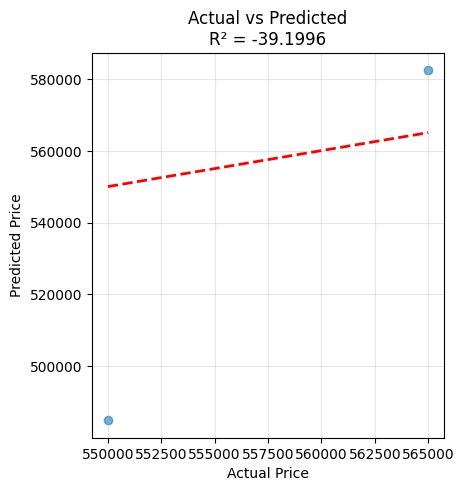

In [ ]:
#@title Multiple Linear Regression Model

"""
SIMPLE MULTIPLE LINEAR REGRESSION MODEL
Dataset: House Price Prediction
"""

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Step 2: Load Dataset
from google.colab import files
print("\nUpload your CSV file:")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print(f"\n✓ Loaded: {filename}")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

# Step 3: Check the Data
print("\nDATA OVERVIEW")

print("\nColumn names:")
print(df.columns.tolist()) # Displaying the names of all columns
print("\nMissing values:")
print(df.isnull().sum()) # Displaying number of NaN values

# Step 4: Handle Missing Values
print("\nHANDLING MISSING VALUES")

# Fill missing values in 'bedrooms' with the mean of the column
df['bedrooms'].fillna(df['bedrooms'].mean(), inplace=True)
print("\nMissing values after handling:")
print(df.isnull().sum())

# Step 5: Select Features and Target
print("\nSELECT YOUR VARIABLES")

# Find target variable (usually contains 'price')
target_col = None
for col in df.columns:
    if 'price' in col.lower():
        target_col = col
        break

if target_col is None:
    # If no 'price' column, use the last column
    target_col = df.columns[-1]

print(f"Target variable: {target_col}")

# Select numeric columns as features (excluding target)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

print(f"Feature variables: {numeric_cols}")

# Prepare X (features) and y (target)
X = df[numeric_cols] #Creating a df containing only the selected feature coloumns
y = df[target_col] #Creating a series containing the target variable

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Step 6: Split Data (80% train, 20% test)
print("\nSPLIT DATA")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# Step 7: Build the Model
print("\nBUILD MODEL")

model = LinearRegression()
model.fit(X_train, y_train)

print("✓ Model trained!")

# Show the equation
print(f"\nIntercept: {model.intercept_:.2f}")
print("\nCoefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.2f}")

# Step 8: Make Predictions
print("\n" + "=" * 50)
print("PREDICTIONS")
print("=" * 50)

y_pred = model.predict(X_test)

# Step 9: Evaluate the Model
print("\nMODEL PERFORMANCE")

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")

if r2 > 0.7:
    print("✓ Good model!")
elif r2 > 0.5:
    print("→ Decent model")
else:
    print("⚠ Model needs improvement")

# Step 10: Visualize Results
print("\nVISUALIZATION")

# Plot 1: Actual vs Predicted
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Actual vs Predicted\nR² = {r2:.4f}')
plt.grid(True, alpha=0.3)

# Step 11: Show Sample Predictions
print("\nSAMPLE PREDICTIONS")
results = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10],
    'Difference': y_test.values[:10] - y_pred[:10]
})
print(results)

print(f"""
SUMMARY:
- Dataset: {filename}
- Features: {len(X.columns)}
- Samples: {len(df)}
- R² Score: {r2:.4f}
- RMSE: {rmse:.2f}
""")